**Sardor Hazratov**
Data Visualization'24 Assignment 1

# Lets import libraries and load the Open Asteroid dataset

In [30]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from datetime import datetime, date

%matplotlib inline

dataset_url = "https://raw.githubusercontent.com/mab253/dataviz_fall24/refs/heads/main/project1-datasets/open-asteroid.csv"

open_asteriod_df = pd.read_csv(dataset_url)
open_asteriod_df.info()

<ipython-input-30-5e83d1d71a25>:10: DtypeWarning: Columns (3,4,16,23,24,70) have mixed types. Specify dtype option on import or set low_memory=False.
  open_asteriod_df = pd.read_csv(dataset_url)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33005 entries, 0 to 33004
Data columns (total 79 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   spkid           33005 non-null  int64  
 1   full_name       33005 non-null  object 
 2   pdes            33005 non-null  object 
 3   name            170 non-null    object 
 4   prefix          1 non-null      object 
 5   neo             33005 non-null  object 
 6   pha             32978 non-null  object 
 7   sats            33005 non-null  int64  
 8   H               33001 non-null  float64
 9   G               13 non-null     float64
 10  M1              0 non-null      float64
 11  M2              0 non-null      float64
 12  K1              0 non-null      float64
 13  K2              0 non-null      float64
 14  PC              0 non-null      float64
 15  diameter        1248 non-null   float64
 16  extent          11 non-null     object 
 17  albedo          1203 non-null  

## Some information about data

`neo` - near earth object (Y/N)  
`pha` - potentially hazardous asteroid (Y/N)  
`H` - absolute magnitude  
`diameter` - object diameter (km)  
`albedo` - geometric albedo, is the parameter that shows amount of light being reflected from the objects surface. https://www.profmatt.com/albedo  
`rot_per` - rotation period (h)  
`epoch_cal` - epoch of osculation in calendar date/time form (TDB)  
`e` - `eccentricity` - is the measure of perfect circular of the orbit. 0 indicates perfect circle. However planet's orbit is not perfect, it is some sort of elliptic. https://www.profmatt.com/eccentricity  
`a` - semi major axis (au)  
`q` - perihelion distance (au), the perihelion, the closest point when it close to the Sun. https://www.profmatt.com/perihelion  
`i` - inclination; angle with respect to x-y ecliptic plane (deg)  
`om` - longitude of the ascending node (deg)
`w` - argument of perihelion (deg)  
`ma` - mean anomaly (deg)  
`ad` - aphelion distance (au) the furthest point when it close to the Sun. https://www.profmatt.com/aphelion  
`n` - mean motion (deg/d)  
`tp_cal` - time of perihelion passage (TDB)
`per` - sidereal orbital period (d)  
`moid` - Earth Minimum Orbit Intersection Distance (au)  
`class` - class of orbit  
`producer` -  name of person (or institution) who computed the orbit

----

`AU` (astronomical unit, measurement) - is the distance between the Sun and the Earth, is typically 1 AU. https://www.profmatt.com/astronomical-unit  

`sideral` - is the time taken to complete one rotation around planet's axis.  https://www.profmatt.com/sidereal  

# Lets start investigating data
Set the `max_columns` parameter to max (of its shape) in order to show all columns

In [6]:
pd.options.display.max_columns = open_asteriod_df.shape[1]

lets print the column names to explore what kind of properties the data have

In [ ]:
open_asteriod_df.columns

Index(['spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'sats',
       'H', 'G', 'M1', 'M2', 'K1', 'K2', 'PC', 'diameter', 'extent', 'albedo',
       'rot_per', 'GM', 'BV', 'UB', 'IR', 'spec_B', 'spec_T', 'H_sigma',
       'diameter_sigma', 'orbit_id', 'epoch', 'epoch_mjd', 'epoch_cal',
       'equinox', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'ad', 'n', 'tp',
       'tp_cal', 'per', 'per_y', 'moid', 'moid_ld', 'moid_jup', 't_jup',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'producer', 'data_arc', 'first_obs', 'last_obs', 'n_obs_used',
       'n_del_obs_used', 'n_dop_obs_used', 'condition_code', 'rms', 'two_body',
       'A1', 'A1_sigma', 'A2', 'A2_sigma', 'A3', 'A3_sigma', 'DT', 'DT_sigma'],
      dtype='object')

In [23]:
# print first 10 rows of data
open_asteriod_df.head(10)

,spkid,full_name,pdes,name,prefix,neo,pha,sats,H,G,M1,M2,K1,K2,PC,diameter,extent,albedo,rot_per,GM,BV,UB,IR,spec_B,spec_T,H_sigma,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,moid_jup,t_jup,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,producer,data_arc,first_obs,last_obs,n_obs_used,n_del_obs_used,n_dop_obs_used,condition_code,rms,two_body,A1,A1_sigma,A2,A2_sigma,A3,A3_sigma,DT,DT_sigma
0,20000433,433 Eros (A898 PA),433,Eros,NaN,Y,N,0,10.41,0.46,NaN,NaN,NaN,NaN,NaN,16.840,34.4x11.2x11.2,0.250,5.27000,0.000446,0.921,0.531,NaN,S,S,NaN,0.06,659,2460200.5,60200,2023-09-13.0,J2000,0.2228,1.458,1.133,10.83,304.29,178.91,222.76,1.78,0.5598,2460445.66,2024-05-15.1,643.0,1.76,0.1480,57.4,3.29,4.58,9.400000e-09,1.600000e-10,1.400000e-08,1.200000e-06,3.600000e-06,4.000000e-06,1.500000e-06,1.900000e-10,9.000000e-11,0.000003,1.000000e-07,AMO,Giorgini,46582.0,1893-10-29,2021-05-13,9130,4.0,2.0,0.0,0.29796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20000719,719 Albert (A911 TB),719,Albert,NaN,Y,N,0,15.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.80100,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,JPL 258,2460200.5,60200,2023-09-13.0,J2000,0.5470,2.636,1.194,11.58,183.85,156.23,56.29,4.08,0.2302,2459956.00,2023-01-11.4,1560.0,4.28,0.2010,78.1,1.42,3.14,2.100000e-08,2.600000e-09,5.700000e-08,2.800000e-06,1.500000e-05,1.500000e-05,2.700000e-06,4.000000e-09,3.400000e-10,0.000012,2.300000e-06,AMO,Otto Matic,40483.0,1911-10-04,2022-08-05,2044,NaN,NaN,0.0,0.40948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20000887,887 Alinda (A918 AA),887,Alinda,NaN,Y,N,0,13.88,-0.12,NaN,NaN,NaN,NaN,NaN,4.200,NaN,0.310,28.41000,NaN,0.832,0.436,NaN,NaN,S,NaN,NaN,JPL 442,2460200.5,60200,2023-09-13.0,J2000,0.5709,2.472,1.061,9.40,110.42,350.47,238.76,3.88,0.2535,2460678.68,2025-01-03.1,1420.0,3.89,0.0789,30.7,1.32,3.22,4.000000e-09,1.300000e-09,9.800000e-09,2.000000e-07,1.700000e-06,1.300000e-06,6.400000e-07,2.000000e-09,2.000000e-10,0.000003,1.100000e-06,AMO,Otto Matic,38506.0,1918-02-03,2023-07-08,3064,NaN,NaN,0.0,0.38101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001036,1036 Ganymed (A924 UB),1036,Ganymed,NaN,Y,N,0,9.26,0.30,NaN,NaN,NaN,NaN,NaN,37.675,NaN,0.238,10.29700,NaN,0.842,0.417,NaN,S,S,NaN,0.40,JPL 1125,2460200.5,60200,2023-09-13.0,J2000,0.5329,2.666,1.245,26.69,215.50,132.48,276.42,4.09,0.2264,2460569.61,2024-09-16.1,1590.0,4.35,0.3450,134.0,1.95,3.03,1.500000e-09,1.600000e-09,3.800000e-09,1.100000e-07,3.500000e-07,3.900000e-07,7.500000e-07,2.500000e-09,2.000000e-10,0.000004,1.400000e-06,AMO,Otto Matic,36088.0,1924-10-23,2023-08-13,9806,0.0,1.0,0.0,0.32487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001221,1221 Amor (1932 EA1),1221,Amor,NaN,Y,N,0,17.37,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JPL 120,2460200.5,60200,2023-09-13.0,J2000,0.4357,1.919,1.083,11.88,171.32,26.65,123.53,2.76,0.3707,2459867.29,2022-10-14.7,971.0,2.66,0.1050,41.0,2.21,3.78,3.300000e-08,9.500000e-10,6.400000e-08,4.400000e-06,1.800000e-05,1.900000e-05,7.400000e-06,1.400000e-09,2.700000e-10,0.000020,7.200000e-07,AMO,Otto Matic,33431.0,1932-03-12,2023-09-22,619,NaN,NaN,0.0,0.45230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,20001566,1566 Icarus (1949 MA),1566,Icarus,NaN,Y,Y,0,16.59,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,0.510,2.27260,NaN,0.774,0.520,NaN,NaN,NaN,NaN,NaN,JPL 156,2460200.5,60200,2023-09-13.0,J2000,0.8269,1.078,0.187,22.80,87.95,31.44,168.65,1.97,0.8805,2460008.96,2023-03-05.4,409.0,1.12,0.0338,13.2,3.22,5.30,1.200000e-08,2.600000e-09,1.300000e-08,3.600000e-06,1.200000e-06,2.000000e-06,8.500000e-06,4.700000e-09,3.200000e-09,0.000009,1.500000e-06,APO,Otto Matic,27042.0,1949-07-01,2023-07-15,1543,10.0,13.0,0.0,0.32244,NaN,NaN,NaN,-3.500000e-15,6.000000e-16,NaN,NaN,NaN,NaN
6,20001580,1580 Betulia (1950 KA),1580,Betulia,NaN,Y,N,0,14.69,0.00,NaN,NaN,NaN,NaN,NaN,5.800,NaN,0.080,6.13240,NaN,0.656,0.249,NaN,NaN,C,NaN,NaN,JPL 281,2460200.5,60200,2023-09-13.0,J2000,0.4870,2.198,

In [34]:
# lets format dates and sort
open_asteriod_df['tp_cal'] = pd.to_datetime(open_asteriod_df['tp_cal'], format="%Y-%m-%d", exact=False)
open_asteriod_df['epoch_cal'] = pd.to_datetime(open_asteriod_df['epoch_cal'], format="%Y-%m-%d", exact=False)
open_asteriod_df = open_asteriod_df.sort_values(by='tp_cal')
open_asteriod_df.head()

,spkid,full_name,pdes,name,prefix,neo,pha,sats,H,G,M1,M2,K1,K2,PC,diameter,extent,albedo,rot_per,GM,BV,UB,IR,spec_B,spec_T,H_sigma,diameter_sigma,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,e,a,q,i,om,w,ma,ad,n,tp,tp_cal,per,per_y,moid,moid_ld,moid_jup,t_jup,sigma_e,sigma_a,sigma_q,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,producer,data_arc,first_obs,last_obs,n_obs_used,n_del_obs_used,n_dop_obs_used,condition_code,rms,two_body,A1,A1_sigma,A2,A2_sigma,A3,A3_sigma,DT,DT_sigma
3165,3012393,(1979 XB),1979 XB,NaN,NaN,Y,Y,0,18.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JPL 13,2444221.5,44221,1979-12-14,J2000,0.7084,2.228,0.650,24.73,86.06,75.58,346.32,3.81,0.2964,2444267.67,1980-01-29,1210.0,3.33,0.023900,9.290,2.08,3.17,0.0600,0.4100,0.01200,1.600,0.1200,0.7300,4.300,0.7100,0.0830,1.700,340.0,APO,Otto Matic,4.0,1979-12-11,1979-12-15,18,NaN,NaN,9.0,0.435270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3170,3092102,(1990 UN),1990 UN,NaN,NaN,Y,N,0,23.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JPL 13,2448191.5,48191,1990-10-27,J2000,0.5281,1.710,0.807,3.68,8.47,97.00,336.32,2.61,0.4408,2448245.22,1990-12-19,817.0,2.24,0.021900,8.540,2.58,4.01,0.0064,0.0200,0.00160,0.048,0.0420,0.0260,0.470,0.0300,0.0077,0.140,14.0,APO,Otto Matic,15.0,1990-10-22,1990-11-06,22,NaN,NaN,9.0,0.191860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3171,3092104,(1991 BA),1991 BA,NaN,NaN,Y,N,0,28.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JPL 12,2448274.5,48274,1991-01-18,J2000,0.6732,2.189,0.715,1.94,118.88,70.69,346.84,3.66,0.3043,2448317.75,1991-03-02,1180.0,3.24,0.000343,0.133,1.30,3.34,0.0440,0.2600,0.01200,0.100,0.0120,0.2600,2.600,0.4300,0.0540,0.950,210.0,APO,Otto Matic,NaN,1991-01-18,1991-01-18,7,NaN,NaN,9.0,0.073238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3173,3092105,(1991 JR),1991 JR,NaN,NaN,Y,N,0,23.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JPL 16,2448388.5,48388,1991-05-12,J2000,0.2609,1.406,1.039,10.14,60.23,207.00,339.27,1.77,0.5914,2448423.54,1991-06-16,609.0,1.67,0.044200,17.200,3.30,4.69,0.0016,0.0033,0.00013,0.045,0.0038,0.0058,0.080,0.0041,0.0021,0.013,2.1,AMO,Otto Matic,11.0,1991-05-08,1991-05-19,20,NaN,NaN,8.0,0.556530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3176,3003148,(1991 VA),1991 VA,NaN,NaN,Y,N,0,26.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JPL 13,2448565.5,48565,1991-11-05,J2000,0.3546,1.434,0.925,6.57,37.65,313.34,24.43,1.94,0.5740,2448522.94,1991-09-23,627.0,1.72,0.007170,2.790,3.48,4.60,0.0016,0.0031,0.00025,0.023,0.0013,0.0088,0.092,0.0042,0.0019,0.022,2.0,APO,Otto Matic,8.0,1991-11-01,1991-11-09,19,NaN,NaN,8.0,0.828580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
# asteriods grouped by their names
open_asteriod_df_grouped = open_asteriod_df['full_name'].value_counts()
open_asteriod_df_grouped.columns = ['Asteroid Name', 'Count']
open_asteriod_df_grouped

,count
full_name,
(1979 XB),1
(2023 RN16),1
469737 (2005 NW44),1
(2015 JD1),1
(1998 QK28),1
...,...
(2022 WV10),1
(2022 YT),1
(2022 QN5),1


So there is no asteroids spotted multiple times. All asteroids recorded only once.  
Lets focus on asteroids observed since 2000

In [44]:
open_asteriod_df_last_2_decade = open_asteriod_df[open_asteriod_df['tp_cal'] > datetime(year=2000,month=1,day=1) ]

[Text(0.5, 1.0, 'Potentially hazardous asteroids (pha) and their magnitude since 2000')]

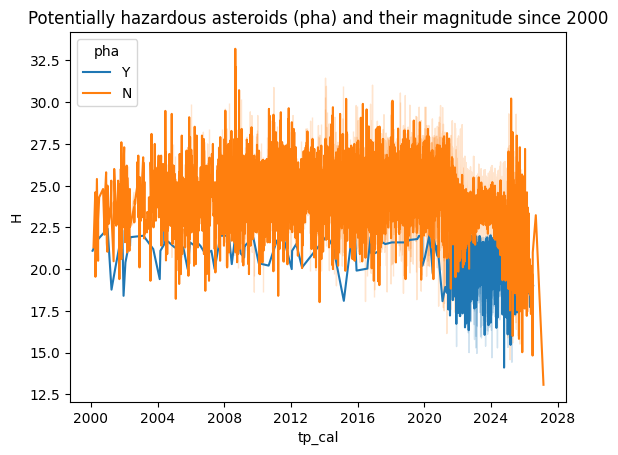

In [85]:
lp= sns.lineplot(data=open_asteriod_df_last_2_decade, x='tp_cal', y='H', hue='pha')
lp.set(title='Potentially hazardous asteroids (pha) and their magnitude since 2000')

Let try another another plot

[]

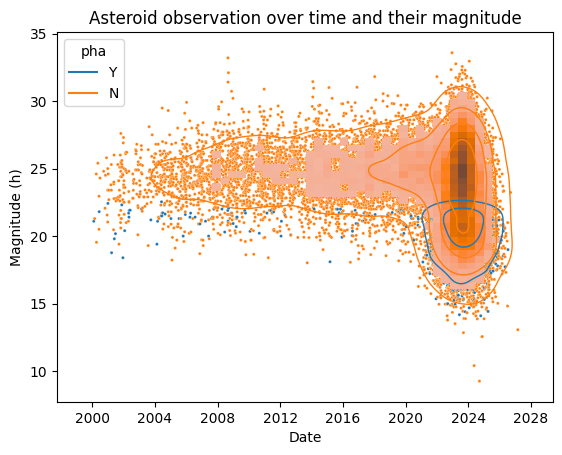

In [65]:
# sns.scatterplot(data=open_asteriod_df_last_2_decade, x='tp_cal', y='H', hue='pha', size='pha', alpha=0.5)
bundled_plot = sns.scatterplot(data=open_asteriod_df_last_2_decade, x='tp_cal', y='H', hue='pha', s=5, color=".15")
bundled_plot = sns.histplot(data=open_asteriod_df_last_2_decade, x='tp_cal', y='H', hue='pha', bins=50, pthresh=.1, cmap="mako")
bundled_plot = sns.kdeplot(data=open_asteriod_df_last_2_decade, x='tp_cal', y='H', hue='pha', levels=5, color="w", linewidths=1)
bundled_plot.set(title='Asteroid observation over time and their magnitude', xlabel='Date', ylabel='Magnitude (h)')
bundled_plot.plot()

It looks like there is a sharp rise in number of asteroids recent years.  
But why? What factors bring asteroids spotted recent years?
Plotting multiple variation of graphs, I came into a guess that this might be producers have added many more records

Lets plot producer's name and their contributions

[Text(0.5, 1.0, 'Unique Observations by Producer Over Time'),
 Text(0.5, 0, 'Date'),
 Text(0, 0.5, 'Number of records')]

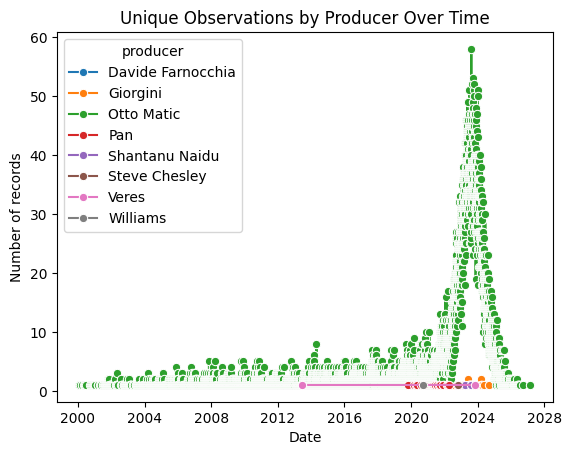

In [63]:
grouped_df = open_asteriod_df_last_2_decade.groupby(['producer', 'tp_cal'])['full_name'].nunique().reset_index()
grouped_df = grouped_df.rename(columns={'full_name': 'count'})
lp = sns.lineplot(data=grouped_df, x='tp_cal', y='count', hue='producer', marker='o')
lp.set(title='Unique Observations by Producer Over Time', xlabel='Date', ylabel='Number of records')


Thank you Otto Matic for numerous work :)

## Q1: How many bright asteroids were there in the past 20 years ?
this is typically albedo value, the reflected light from surface of the object

In [66]:
# how many NA values in the dataset
albedo_na_count = open_asteriod_df_last_2_decade['albedo'].isna().sum()
print(albedo_na_count)

31718


Thats a huge amount of data, though lets drop them

In [72]:
# lets clean a bit NaN values for certain columns
open_asteriod_df_last_2_decade_clean = open_asteriod_df_last_2_decade.dropna(subset=["albedo"])
open_asteriod_df_last_2_decade_clean = open_asteriod_df_last_2_decade_clean.groupby(['tp_cal', 'albedo'])['full_name'].nunique().reset_index()
open_asteriod_df_last_2_decade_clean

,tp_cal,albedo,full_name
0,2009-12-07,0.548,1
1,2009-12-26,0.080,1
2,2010-01-24,0.497,1
3,2010-02-13,0.303,1
4,2010-04-06,0.032,1
...,...,...,...
1197,2026-03-30,0.020,1
1198,2026-05-05,0.038,1
1199,2026-05-23,0.061,1
1200,2026-05-27,0.034,1


[]

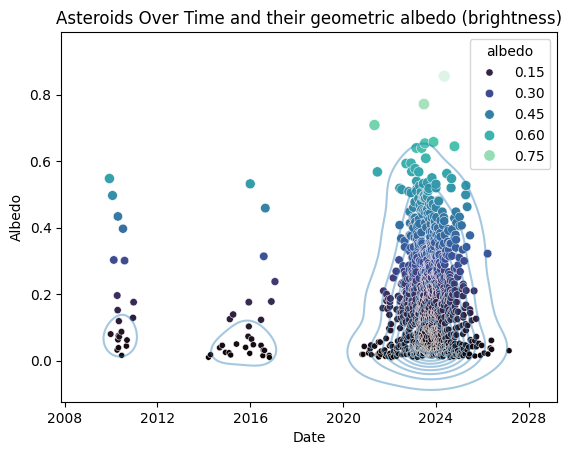

In [223]:
lp_q1 = sns.scatterplot(data=open_asteriod_df_last_2_decade_clean, x='tp_cal', y='albedo', hue='albedo', size='albedo', palette='mako')
lp_q1 = sns.kdeplot(data=open_asteriod_df_last_2_decade_clean, x='tp_cal', y='albedo', alpha=0.4)
lp_q1.set(title='Asteroids Over Time and their geometric albedo (brightness)', xlabel='Date', ylabel='Albedo')
lp_q1.plot()

**Answer is that many asteroids are dark objects, but still there are some shiny ones**

## Lets observe the data relationship

How diameter parameter is distributed among asteroids?

[Text(0.5, 1.0, 'Asteroid diameter distribution')]

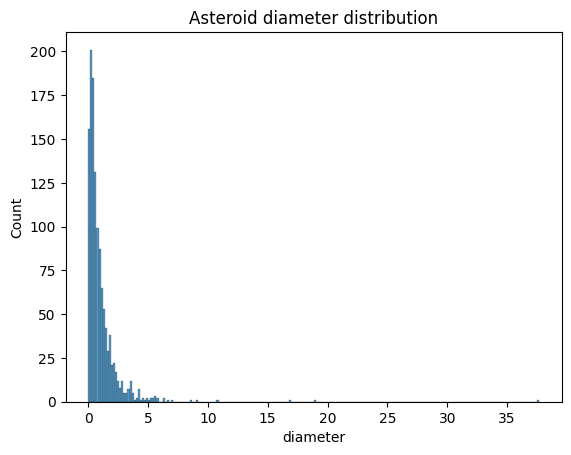

In [122]:
hp = sns.histplot(data=open_asteriod_df, x='diameter')
hp.set(title='Asteroid diameter distribution')

Lets see asteroids with diameter less than 6km

[Text(0.5, 1.0, 'Asteroid diameter distribution (less than 6 km)')]

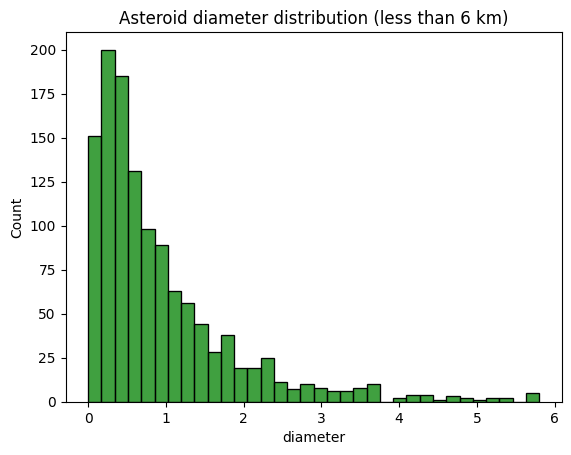

In [125]:
open_asteriod_df_less_6 = open_asteriod_df[open_asteriod_df['diameter'] < 6]
# open_asteriod_df_less_6.describe()
hp = sns.histplot(data=open_asteriod_df_less_6, x='diameter', color='green')
hp.set(title='Asteroid diameter distribution (less than 6 km)')

Lets see asteroids with diameter more than 6km

[Text(0.5, 1.0, 'Asteroid diameter distribution (more than 6 km)')]

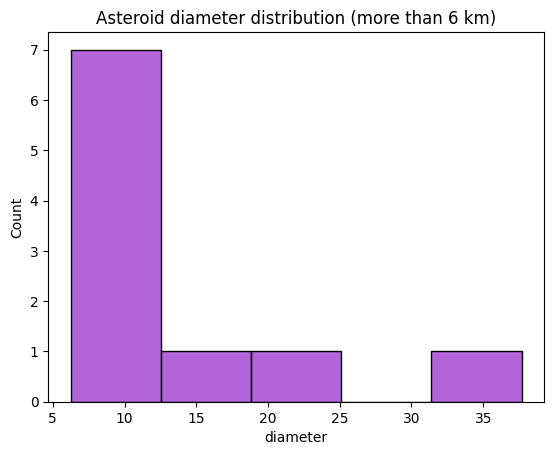

In [126]:
open_asteriod_df_more_6 = open_asteriod_df[open_asteriod_df['diameter'] >= 6]
# open_asteriod_df_more_6.describe()
hp = sns.histplot(data=open_asteriod_df_more_6, x='diameter', color='darkorchid')
hp.set(title='Asteroid diameter distribution (more than 6 km)')

Lets see now how the `eccentricity` distributed

[Text(0.5, 1.0, 'Asteroid eccentricity distribution')]

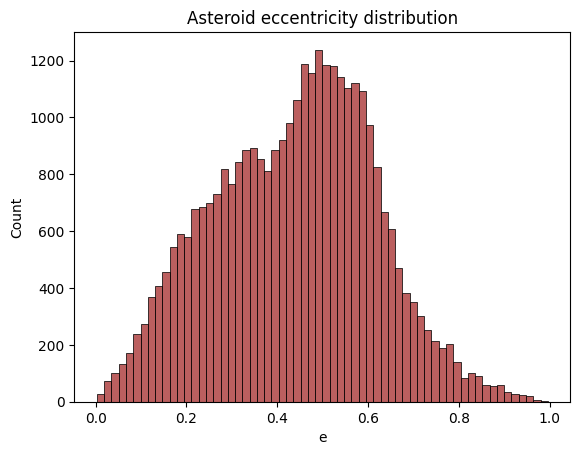

In [128]:
hp = sns.histplot(data=open_asteriod_df, x='e', color='brown')
hp.set(title='Asteroid eccentricity distribution')

There are many properties that we need to take a look closer to see what kind of relationships they have.  
So I created a list of properties I want to see as sns.pairplot()


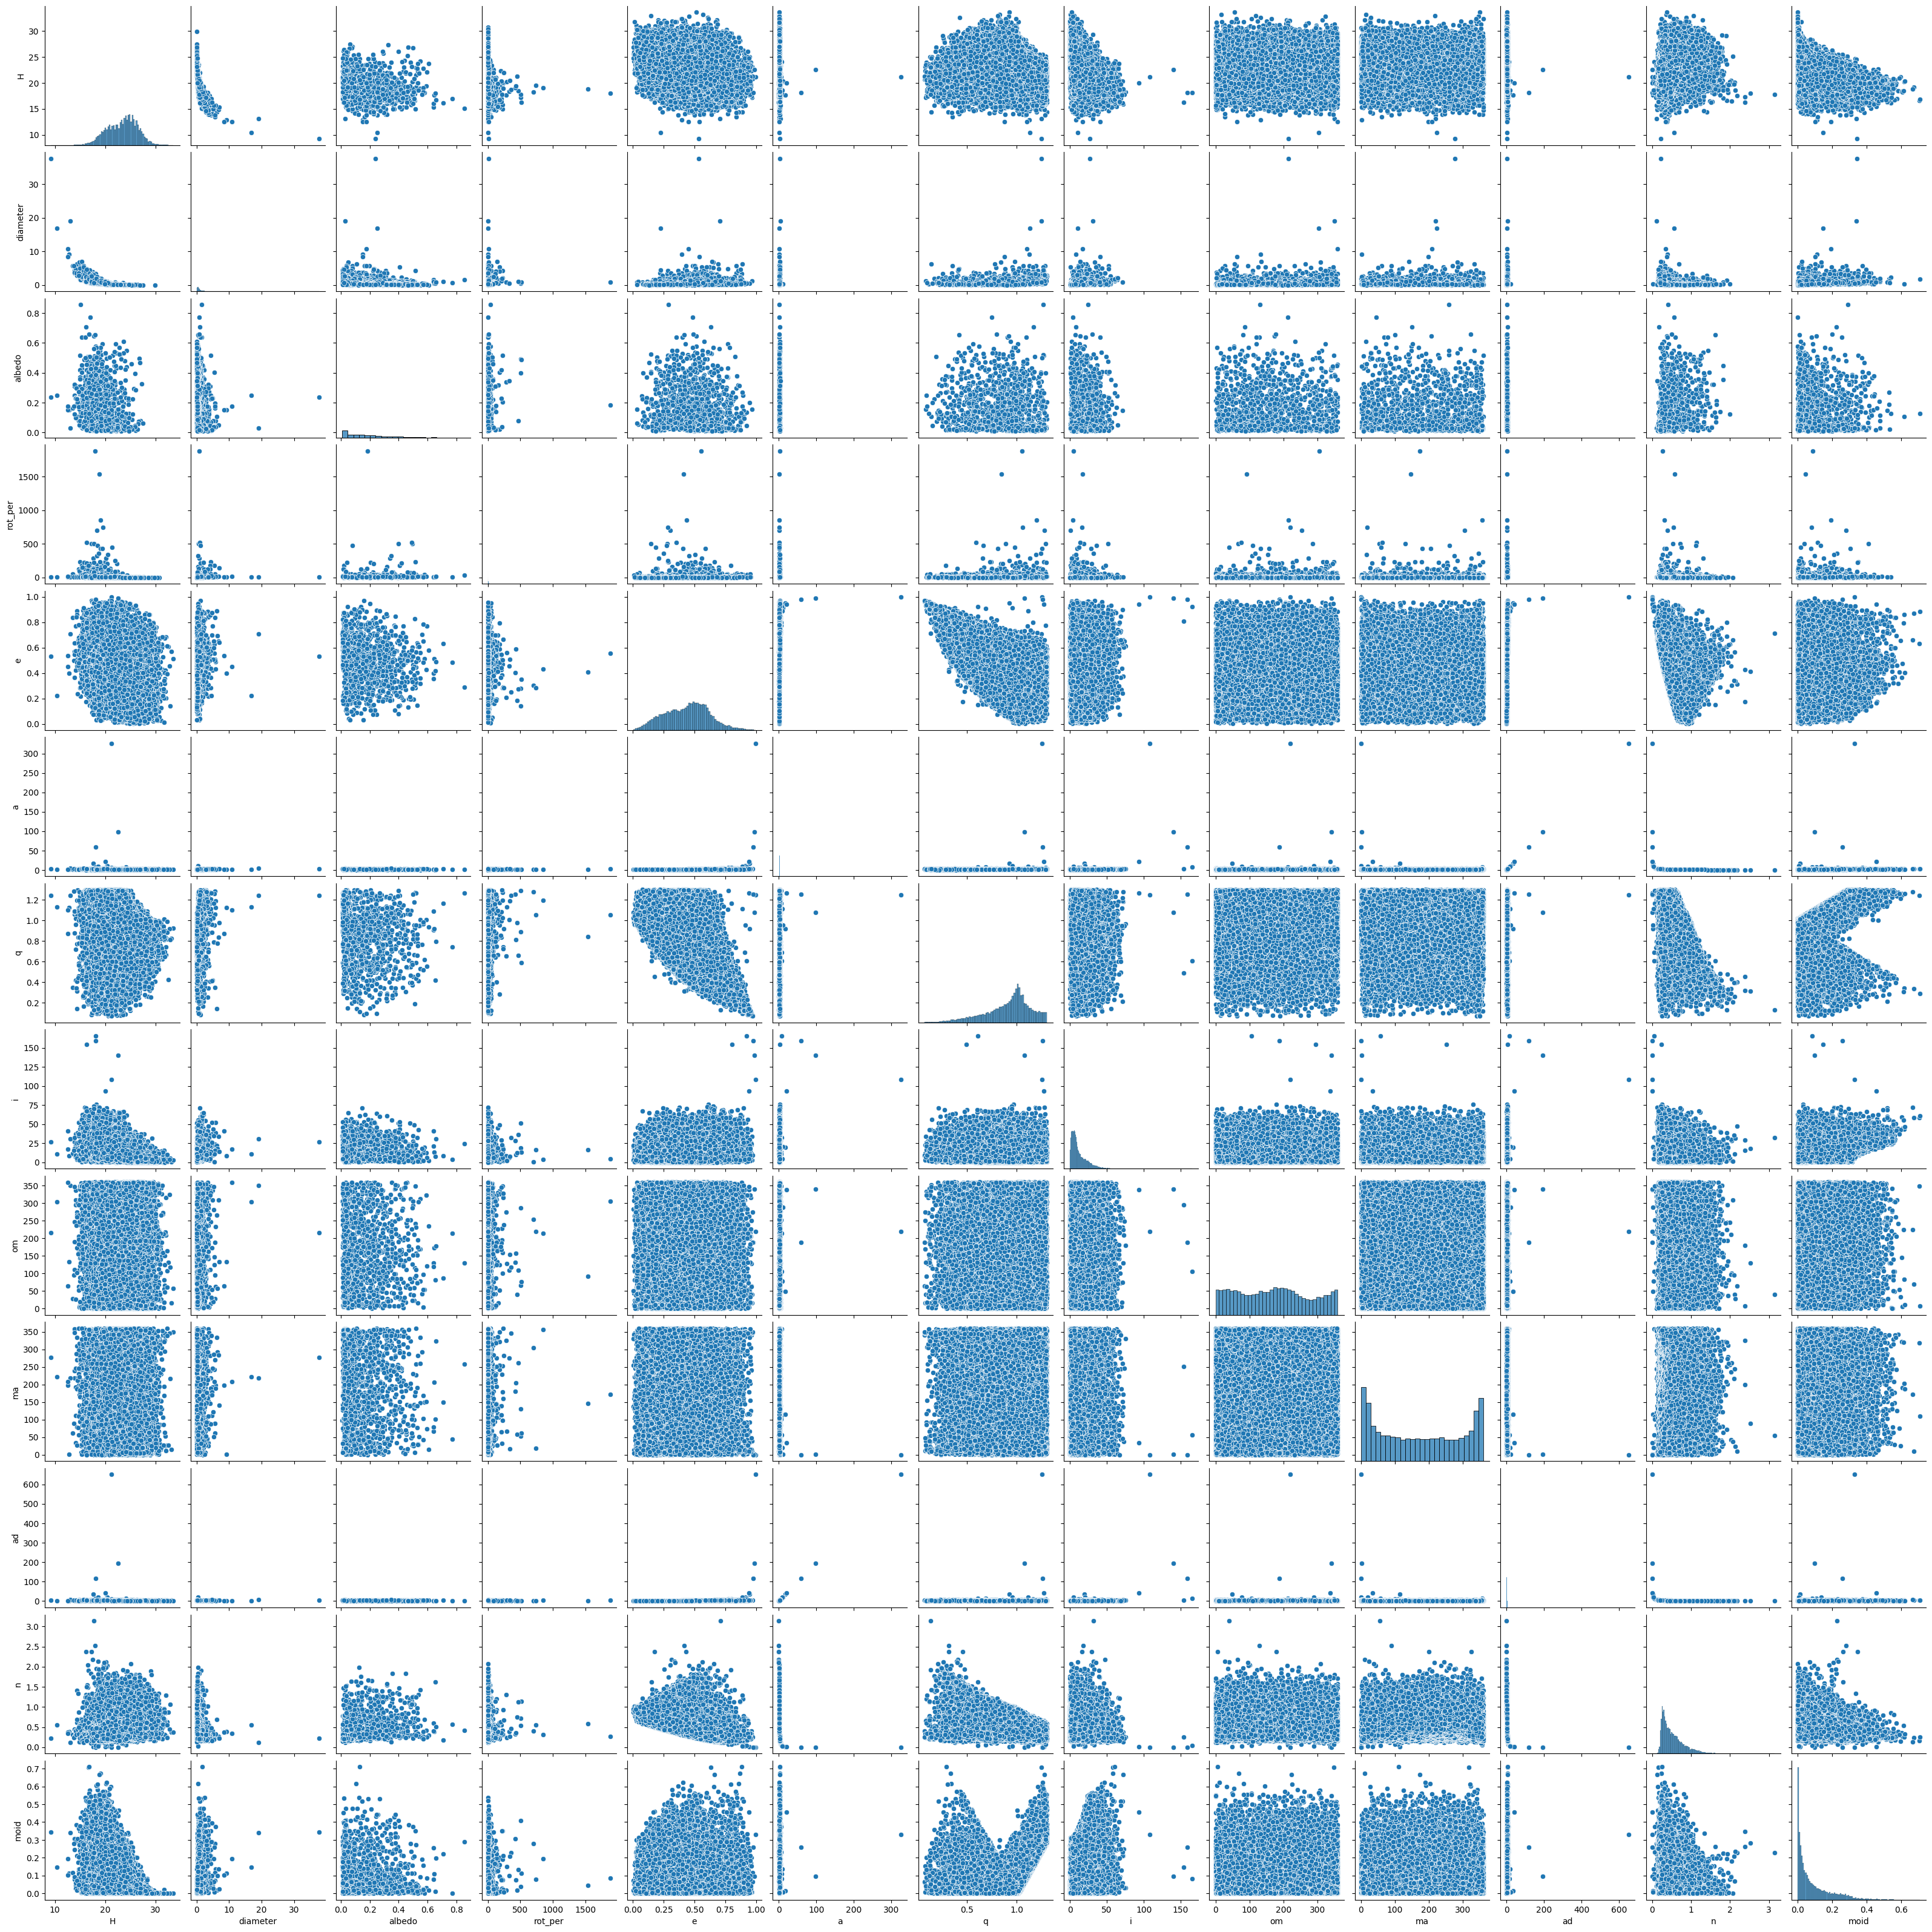

In [ ]:
columns_of_interest = ["H", "diameter", "albedo", "rot_per", 'e', 'a', 'q', 'i', 'om', 'ma', 'ad', 'n', 'moid']
open_asteriod_df_col_interest = open_asteriod_df[columns_of_interest]
sns.pairplot(data=open_asteriod_df_col_interest)

Data looks scary :)

At first glance there seems to be no relation between properties  
Lets see some of the relationships closer if there is some correlation

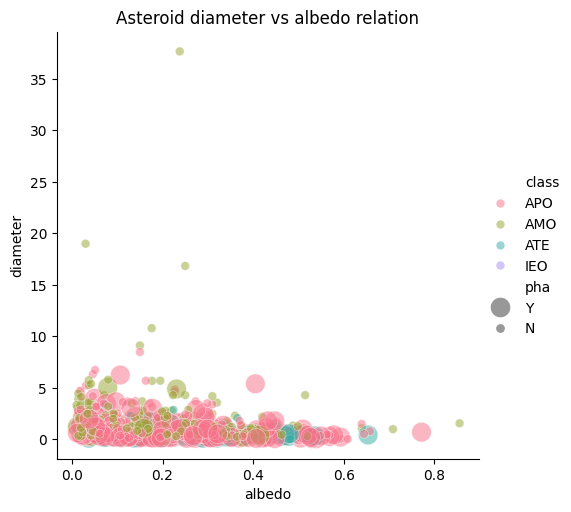

In [212]:
rp = sns.relplot(data=open_asteriod_df, x='albedo', y='diameter', hue='class', size="pha", sizes=(40, 200), alpha=0.5, palette='husl')
rp.set(title='Asteroid diameter vs albedo relation')

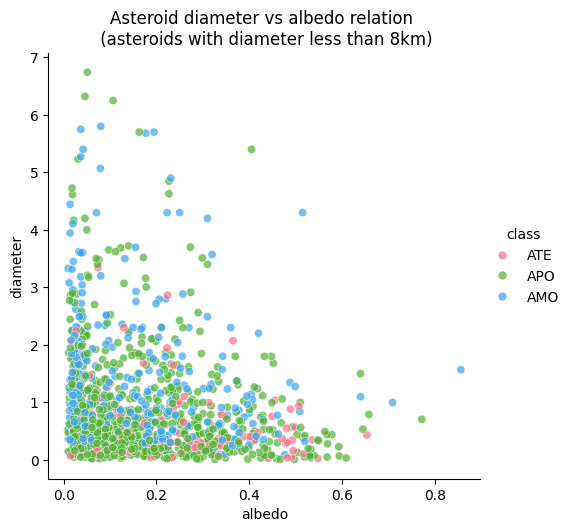

In [214]:
rp = sns.relplot(data=open_asteriod_df[open_asteriod_df['diameter'] < 8 ], x='albedo', y='diameter', hue='class', alpha=0.7, palette='husl')
rp.set(title='Asteroid diameter vs albedo relation \n (asteroids with diameter less than 8km)')

[Text(0.5, 1.0, 'Asteroid classes and their mean nomaly degrees (ma)')]

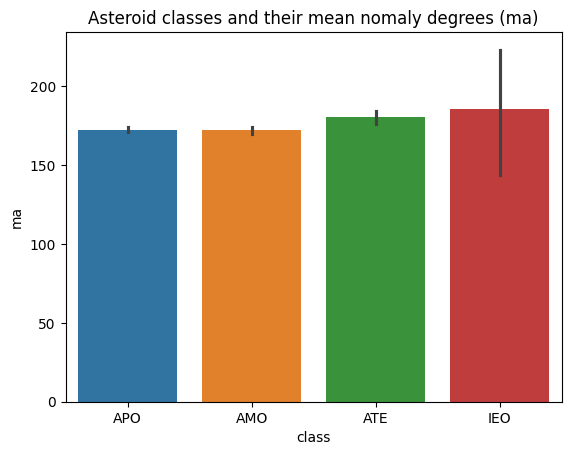

In [86]:
bp = sns.barplot(data=open_asteriod_df, x='class', y='ma', hue='class')
bp.set(title='Asteroid classes and their mean nomaly degrees (ma)')

Interesting fact that paremeter `e` and `q` (eccentricity and perihelion distance) has some negative correlation.  

<Axes: xlabel='e', ylabel='q'>

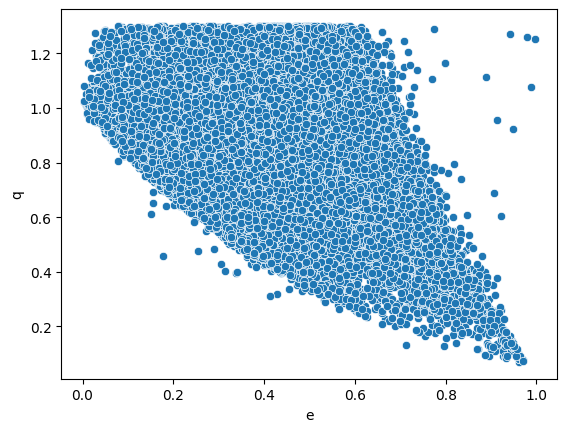

In [ ]:
sns.scatterplot(data=open_asteriod_df, x='e', y='q')

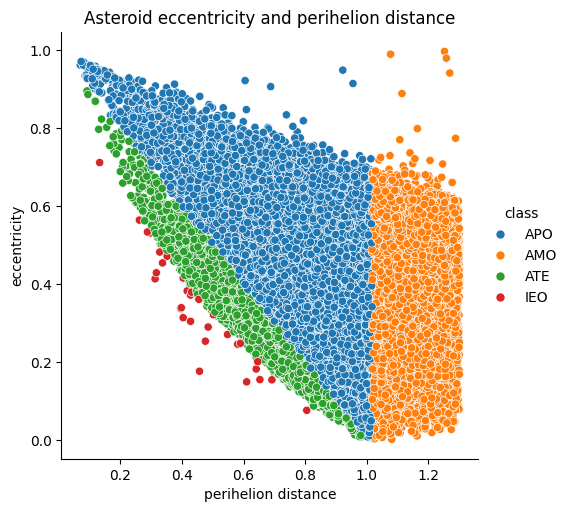

In [87]:
rplot = sns.relplot(data=open_asteriod_df, x='q', y='e', hue='class')
rplot.set(title='Asteroid eccentricity and perihelion distance', xlabel='perihelion distance', ylabel='eccentricity')

Does the asteroid diameter affect its eccentricity?

[Text(0.5, 1.0, 'Asteroid eccentricity Quartiles and outliers per class'),
 Text(0, 0.5, 'Eccentricity')]

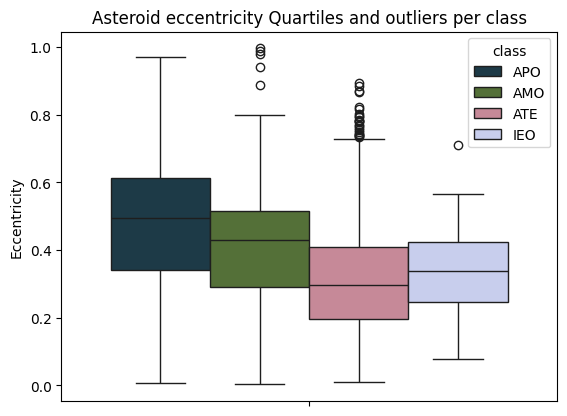

In [144]:
bp= sns.boxplot(data=open_asteriod_df, y="e",  hue="class", palette='cubehelix', legend='brief')
bp.set(title='Asteroid eccentricity Quartiles and outliers per class', ylabel='Eccentricity')

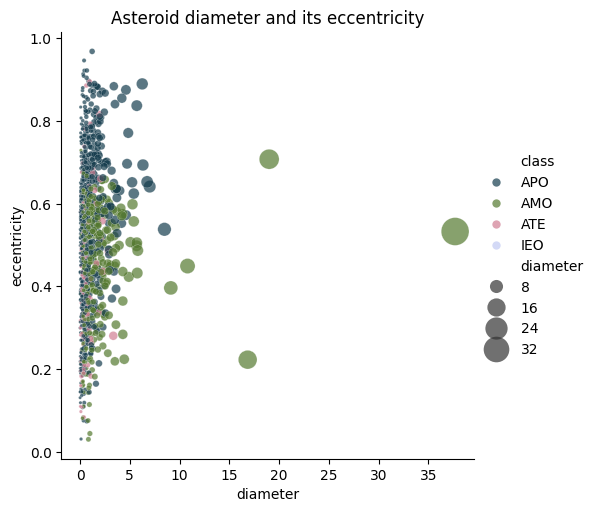

In [105]:
rp = sns.relplot(data=open_asteriod_df, x="diameter", y="e", hue="class", size="diameter", sizes=(5, 400), alpha=.7, palette='cubehelix', height=5, legend='brief')
rp.set(title='Asteroid diameter and its eccentricity', xlabel='diameter', ylabel='eccentricity')

lets drop outliers with diameter over 15

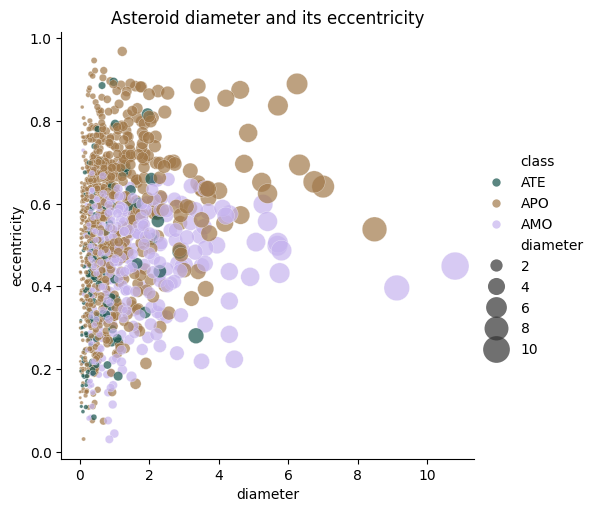

In [104]:
open_asteriod_df_clean_diameter = open_asteriod_df[open_asteriod_df['diameter'] < 15]
rp = sns.relplot(data=open_asteriod_df_clean_diameter, x="diameter", y="e", hue="class", size="diameter", sizes=(5, 400), alpha=.7, palette='cubehelix', height=5, legend='brief')
rp.set(title='Asteroid diameter and its eccentricity', xlabel='diameter', ylabel='eccentricity')

Does the Magnitude and diameter affect perihelion distance ?

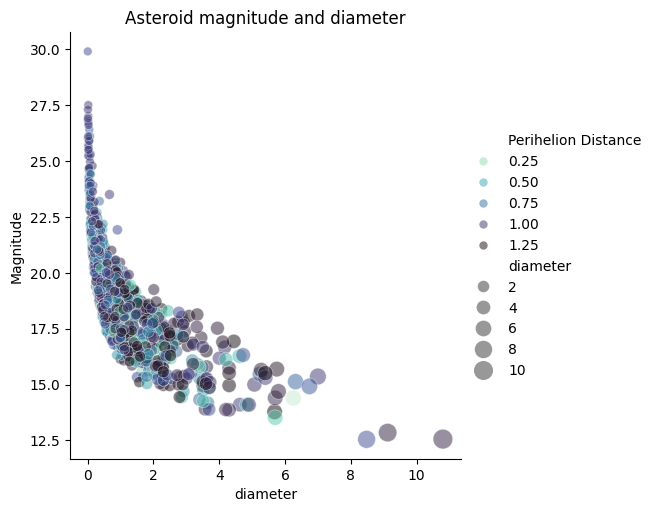

In [148]:
open_asteriod_df_clean_diameter = open_asteriod_df_clean_diameter.rename(columns={'H': 'Magnitude', 'q': 'Perihelion Distance'})
rp = sns.relplot(x="diameter", y="Magnitude", hue="Perihelion Distance", size="diameter", sizes=(40,200),  alpha=.5, palette='mako_r', data=open_asteriod_df_clean_diameter)
rp.set(title='Asteroid magnitude and diameter')

More the diameter it becomes less magnitude

## Q2: How far were the asteroids when they were recorded ?

Text(0.5, 0.98, 'Asteroid - Earth Minimum Orbit Intersection Distance per orbit class since 2000 per class')

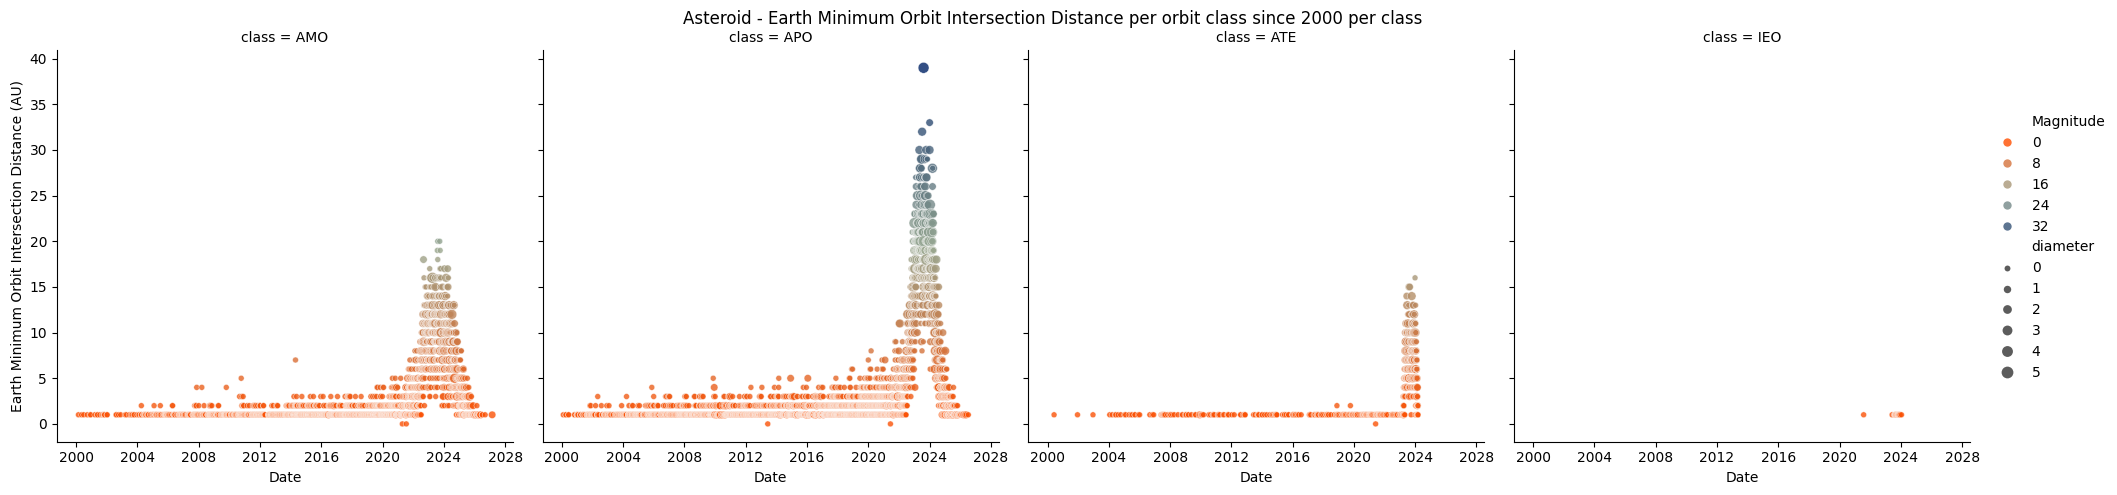

In [219]:
open_asteriod_df_last_2_decade = open_asteriod_df_last_2_decade.rename(columns={'H': 'Magnitude', 'q': 'Perihelion Distance'})
open_asteriod_df_last_2_decade_grouped_class = open_asteriod_df_last_2_decade.groupby(['class', 'tp_cal']).count()

colors = ['#FF4F00', '#97a892', '#002366']
pl = sns.blend_palette(colors, 2, as_cmap=True)
# pl = sns.color_palette("flare", as_cmap=True)
rp = sns.relplot(
    data=open_asteriod_df_last_2_decade_grouped_class,
    x="tp_cal", y="moid",
    col="class", hue='Magnitude', size='diameter', alpha = 0.8,
    kind="scatter", palette=pl, height=5
)
rp.set_xlabels('Date')
rp.set_ylabels('Earth Minimum Orbit Intersection Distance (AU)')
rp.fig.subplots_adjust(top=0.9)
rp.fig.suptitle('Asteroid - Earth Minimum Orbit Intersection Distance per orbit class since 2000 per class')

It seems like orbit class of `IEO` is fewer recorded. But most of the asteoids seems like either `AMO` or `APO` class asteroids. `APO` orbit class asteroids were the most farthest asteroids recorded.

# Final Report

**About Asteroids**:  
Asteroids are small rocky objects that orbit the Sun, mostly found in the region called as Asteroid Belt. They are remnants from the early solar system. While the majority of asteroids remain confined to the asteroid belt, some have orbits that bring them closer to Earth. These are known as Near-Earth Asteroids (NEAs). Some NEAs occasionally cross Earth's orbit, and while most pose no threat.  

Studying asteroids is critical for several reasons. First, these bodies are considered time capsules from the early solar system, offering direct information about its composition and evolution. Second, asteroids may contain valuable resources such as water, metals, and even rare minerals that could support future space exploration missions or even be mined for use on Earth. Water, for instance, could be converted into hydrogen and oxygen for fuel, making asteroids potential refueling stations for spacecraft.

The Asteroid dataset contains records of large number of asteroids recorded and their properties. Although, some properties of most asteroids are missing, there is still enough data to observe features.  

I have choosen this dataset because I find it interesting to learn astronomy. Particularly, it helped me to get insights about asteroids and their characteristics. The dateset required a lot of effort to learn first of all about astronomy and then space objects.  
During the observation of the dataset I could not find relevance of asteroids to each other. They appear unique space objects as its nature. Each of it has different diameter, rotation period, eccentricity and magnitude.  
Eccentricity can be explained with this image comparing different levels of it  

![image](https://astronomy.swin.edu.au/cms/cpg15x/albums/userpics/eccentricity.jpg)

Conducting this research about dataset, I tried to find relationships between properties like eccentricity, magnitude, diameter, albedo, MOID and Perihelion distance. However there is nothing I could tell about relationship of the parameters. Each asteroid has unique surface that partially may or may not reflect the Sun light. I found out that generally as diameter increases their magnitude drops, these values are inversely proportional.


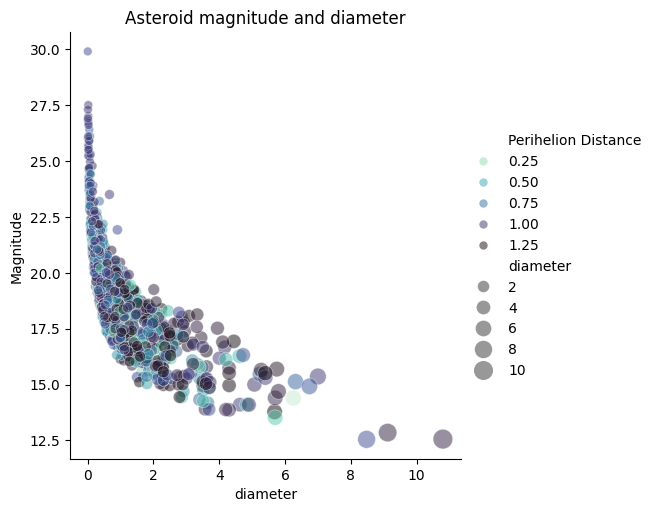

In [215]:
open_asteriod_df_clean_diameter = open_asteriod_df_clean_diameter.rename(columns={'H': 'Magnitude', 'q': 'Perihelion Distance'})
rp = sns.relplot(x="diameter", y="Magnitude", hue="Perihelion Distance", size="diameter", sizes=(40,200),  alpha=.5, palette='mako_r', data=open_asteriod_df_clean_diameter)
rp.set(title='Asteroid magnitude and diameter')

I also tried to understand what factors affect the asteroid geometric albedo (light reflected from the surface)  
It turned out that most of the asteroid observed during 2020 and 2024 are just dark celestial bodies. Only minority of them reflects light.

[]

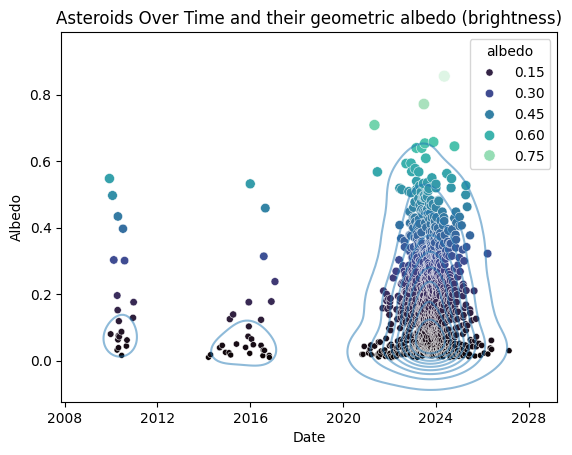

In [226]:
lp = sns.scatterplot(data=open_asteriod_df_last_2_decade_clean, x='tp_cal', y='albedo', hue='albedo', size='albedo', palette='mako')
lp = sns.kdeplot(data=open_asteriod_df_last_2_decade_clean, x='tp_cal', y='albedo', alpha=0.5)
lp.set(title='Asteroids Over Time and their geometric albedo (brightness)', xlabel='Date', ylabel='Albedo')
lp.plot()

Then I tried to understand how close the asteroids from each class orbit were when they were recorded since 2000.  
It seems like orbit class of IEO is fewer recorded. But most of the asteoids seems like either AMO or APO class asteroids. APO orbit class asteroids were the most farthest asteroids recorded.

Text(0.5, 0.98, 'Asteroid - Earth Minimum Orbit Intersection Distance per orbit class since 2000 per class')

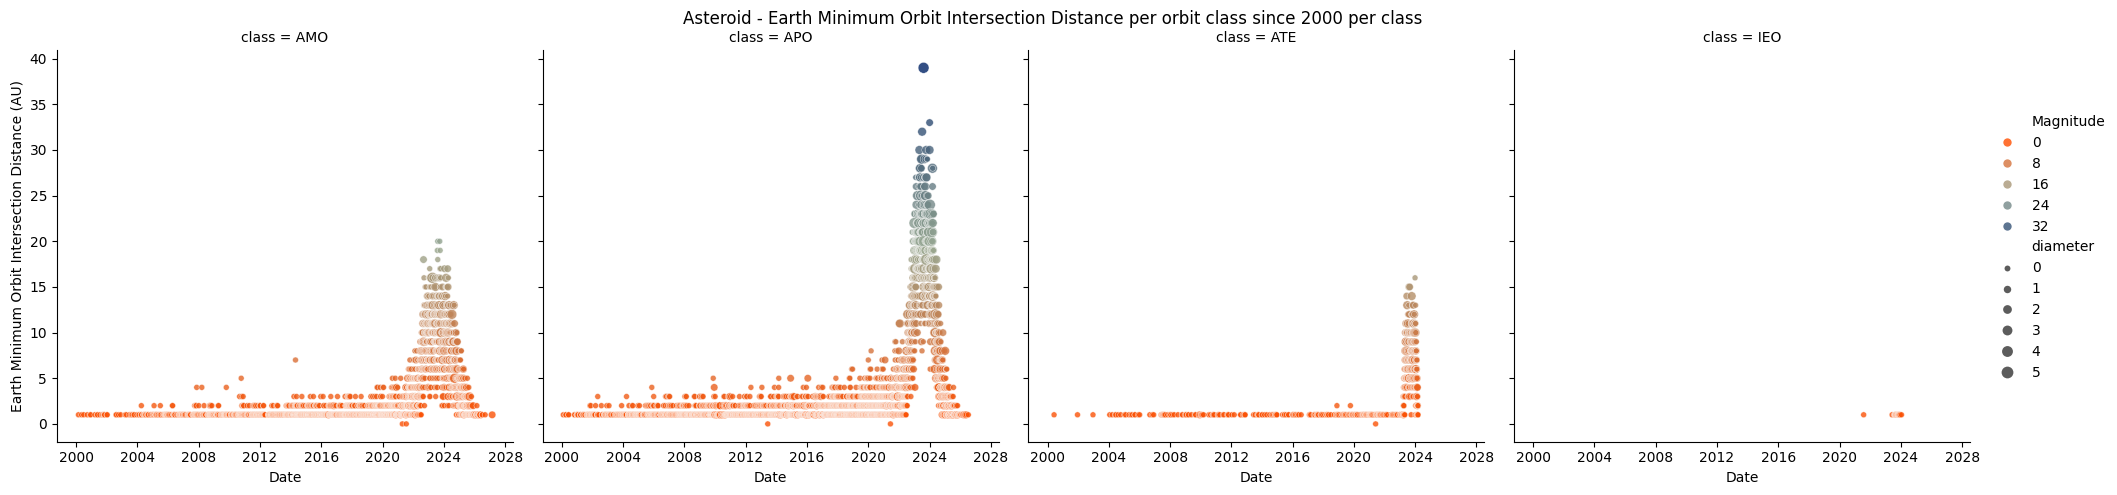

In [227]:
open_asteriod_df_last_2_decade = open_asteriod_df_last_2_decade.rename(columns={'H': 'Magnitude', 'q': 'Perihelion Distance'})
open_asteriod_df_last_2_decade_grouped_class = open_asteriod_df_last_2_decade.groupby(['class', 'tp_cal']).count()

colors = ['#FF4F00', '#97a892', '#002366']
pl = sns.blend_palette(colors, 2, as_cmap=True)
# pl = sns.color_palette("flare", as_cmap=True)
rp = sns.relplot(
    data=open_asteriod_df_last_2_decade_grouped_class,
    x="tp_cal", y="moid",
    col="class", hue='Magnitude', size='diameter', alpha = 0.8,
    kind="scatter", palette=pl, height=5
)
rp.set_xlabels('Date')
rp.set_ylabels('Earth Minimum Orbit Intersection Distance (AU)')
rp.fig.subplots_adjust(top=0.9)
rp.fig.suptitle('Asteroid - Earth Minimum Orbit Intersection Distance per orbit class since 2000 per class')